# Edit Predictor Supervised Baseline — Lexical Complex-Word Training

This notebook trains and evaluates the token-level Edit Predictor (K/M classifier) using the **lexical complex-word pseudo-label dataset** generated from `explanation/data/cefr_vocabularies.csv`.

**Current active data flow:**

```text
explanation/data/cefr_vocabularies.csv
+ explanation/data/sentences.txt
  -> explanation/data/processed/complex_words_pseudo_labels.jsonl
  -> explanation/data/processed/edit_predictor_token_labels_complex_words_distilbert_max256.pt
  -> this notebook trains/evaluates the Edit Predictor checkpoint
```

**What this notebook trains:** the supervised baseline Edit Predictor. Given token IDs, the model predicts `K` (keep / not difficult) or `M` (mask / difficult) per token.

**What this notebook does NOT do:**
- No adversarial training (confusion loss, invariance loss).
- No frozen discriminator signal.
- No synonym substitution / Difficulty-aware Filling.
- No calls to Groq or OpenRouter.
- Does not read `cefr_vocabularies.csv` directly during training; the CSV is already converted into JSONL (via `generate_complex_word_pseudo_labels.py`) and then into the `.pt` token dataset.

**Important:** this notebook expects the `.pt` file to already exist:

```text
explanation/data/processed/edit_predictor_token_labels_complex_words_distilbert_max256.pt
```


## 1. Setup

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    markers = [
        Path("explanation") / "model" / "train_edit_predictor.py",
        Path("explanation") / "scripts" / "build_edit_predictor_dataset.py",
        Path("explanation") / "scripts" / "generate_complex_word_pseudo_labels.py",
    ]

    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers[:2]):
            return candidate

    raise FileNotFoundError(
        "Could not find the repository root. "
        "Open this notebook from inside responsible-ai-system-design, "
        "or set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"cwd  : {Path.cwd()}")
print(f"root : {PROJECT_ROOT}")


cwd  : /home/kenai/projects/responsible-ai-system-design/notebooks/explanation
root : /home/kenai/projects/responsible-ai-system-design


In [2]:
import sys
import subprocess
import torch

print(f"Python : {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch CUDA  : {torch.version.cuda}")

CUDA_DEVICE_INDEX = 0

if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    DEVICE = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
    print(f"Device        : {DEVICE}")
    print(f"GPU           : {torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}")

    try:
        torch.set_float32_matmul_precision("high")
        print("Matmul precision: high")
    except Exception as exc:
        print(f"Matmul precision not changed: {exc}")

    try:
        result = subprocess.run(["nvidia-smi"], check=False, capture_output=True, text=True)
        if result.returncode == 0:
            print("\n=== nvidia-smi ===")
            print(result.stdout)
    except FileNotFoundError:
        print("nvidia-smi not found in this environment.")
else:
    DEVICE = torch.device("cpu")
    print("Device        : CPU (training will be slow; a GPU kernel is recommended)")


Python : 3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]
PyTorch: 2.12.1+cu130
CUDA available: True
PyTorch CUDA  : 13.0
Device        : cuda:0
GPU           : NVIDIA GeForce RTX 3060
Matmul precision: high

=== nvidia-smi ===
Wed Jul  1 22:33:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.61                 Driver Version: 595.95         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        On  |   00000000:01:00.0  On |                  N/A |
|  

In [3]:
PSEUDO_LABEL_FILE = PROJECT_ROOT / "explanation" / "data" / "processed" / \
    "complex_words_pseudo_labels.jsonl"

DATASET_FILE = PROJECT_ROOT / "explanation" / "data" / "processed" / \
    "edit_predictor_token_labels_complex_words_distilbert_max256.pt"

OUTPUT_DIR = PROJECT_ROOT / "explanation" / "model" / "checkpoints" / \
    "edit_predictor_complex_words_distilbert_max256_big_final"

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

EPOCHS = 12
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 0.001
SEED = 13
USE_CLASS_WEIGHTS = True
MASK_CLASS_WEIGHT = None 

print("Configuration loaded.")
print(f"  pseudo_label_file       : {PSEUDO_LABEL_FILE}")
print(f"  dataset_file            : {DATASET_FILE}")
print(f"  output_dir              : {OUTPUT_DIR}")
print(f"  model_name              : {MODEL_NAME}")
print(f"  max_length              : {MAX_LENGTH}")
print(f"  epochs                  : {EPOCHS}")
print(f"  batch_size              : {BATCH_SIZE}")
print(f"  learning_rate           : {LEARNING_RATE}")
print(f"  use_class_weights       : {USE_CLASS_WEIGHTS}")
print(f"  mask_class_weight       : {MASK_CLASS_WEIGHT}")

if not DATASET_FILE.exists():
    build_command = """
.venv/bin/python -m explanation.scripts.build_edit_predictor_dataset \\
  --input-file explanation/data/processed/complex_words_pseudo_labels.jsonl \\
  --output-file explanation/data/processed/edit_predictor_token_labels_complex_words_distilbert_max256.pt \\
  --model-name distilbert-base-uncased \\
  --max-length 256 \\
  --train-ratio 0.8 \\
  --validation-ratio 0.1 \\
  --test-ratio 0.1 \\
  --seed 13
""".strip()
    message = (
        f"Token dataset not found: {DATASET_FILE}\n"
        f"Build it first with:\n{build_command}"
    )
    raise FileNotFoundError(message)

if not PSEUDO_LABEL_FILE.exists():
    print(f"Warning: pseudo-label JSONL not found: {PSEUDO_LABEL_FILE}")
    print("This is not required for training if DATASET_FILE already exists, but keep it for reproducibility.")


Configuration loaded.
  pseudo_label_file       : /home/kenai/projects/responsible-ai-system-design/explanation/data/processed/complex_words_pseudo_labels.jsonl
  dataset_file            : /home/kenai/projects/responsible-ai-system-design/explanation/data/processed/edit_predictor_token_labels_complex_words_distilbert_max256.pt
  output_dir              : /home/kenai/projects/responsible-ai-system-design/explanation/model/checkpoints/edit_predictor_complex_words_distilbert_max256_big_final
  model_name              : distilbert-base-uncased
  max_length              : 256
  epochs                  : 12
  batch_size              : 16
  learning_rate           : 2e-05
  use_class_weights       : True
  mask_class_weight       : None


## 2. Load token dataset

This notebook loads the already-built `.pt` token dataset. The `.pt` file contains train/validation/test splits with `input_ids`, `attention_mask`, and token-level `labels`.

The label convention is:

```text
0    K     keep / not difficult
1    M     mask / difficult
-100       special token or padding, ignored by loss and metrics
```


In [4]:
import json

from explanation.model.train_edit_predictor import load_token_dataset

dataset = load_token_dataset(DATASET_FILE)

print("=== metadata ===")
print(json.dumps(dataset["metadata"], indent=2))


=== metadata ===
{
  "input_file": "explanation/data/processed/complex_words_pseudo_labels.jsonl",
  "model_name": "distilbert-base-uncased",
  "max_length": 256,
  "label_keep": 0,
  "label_mask": 1,
  "label_ignore": -100,
  "rows_read": 12536,
  "rows_written": 9537,
  "rows_skipped_malformed": 0,
  "invalid_spans_ignored": 0,
  "out_of_bounds_spans_ignored": 0,
  "examples_no_difficult_words": 2999,
  "tokens_keep": 269452,
  "tokens_mask": 24700,
  "tokens_ignore": 2147320,
  "rows_skipped": 2999,
  "train_examples": 7629,
  "validation_examples": 953,
  "test_examples": 955
}


In [5]:
print("=== split sizes ===")
for split in ["train", "validation", "test"]:
    n = dataset[split]["input_ids"].shape[0]
    print(f"  {split:<10}: {n} examples")

print()
print("=== tensor shapes ===")
for split in ["train", "validation", "test"]:
    for key in ["input_ids", "attention_mask", "labels"]:
        print(f"  {split}.{key:<15}: {tuple(dataset[split][key].shape)}")


=== split sizes ===
  train     : 7629 examples
  validation: 953 examples
  test      : 955 examples

=== tensor shapes ===
  train.input_ids      : (7629, 256)
  train.attention_mask : (7629, 256)
  train.labels         : (7629, 256)
  validation.input_ids      : (953, 256)
  validation.attention_mask : (953, 256)
  validation.labels         : (953, 256)
  test.input_ids      : (955, 256)
  test.attention_mask : (955, 256)
  test.labels         : (955, 256)


## 3. Dataset audit

In [6]:
import pandas as pd

from explanation.model.edit_predictor import LABEL_IGNORE, LABEL_KEEP, LABEL_MASK

audit_rows = []
for split in ["train", "validation", "test"]:
    labels = dataset[split]["labels"]
    n_keep = int((labels == LABEL_KEEP).sum())
    n_mask = int((labels == LABEL_MASK).sum())
    n_ignore = int((labels == LABEL_IGNORE).sum())
    n_examples_with_m = int((labels == LABEL_MASK).any(dim=1).sum())
    n_all_keep_examples = int(
        ((labels == LABEL_MASK).sum(dim=1) == 0).sum()
    )
    audit_rows.append({
        "split": split,
        "tokens_K": n_keep,
        "tokens_M": n_mask,
        "tokens_ignore": n_ignore,
        "pct_M_of_valid": round(100 * n_mask / max(n_keep + n_mask, 1), 2),
        "examples_with_M": n_examples_with_m,
        "all_K_examples": n_all_keep_examples,
        "total_examples": labels.shape[0],
    })

audit_df = pd.DataFrame(audit_rows)
print(audit_df.to_string(index=False))


     split  tokens_K  tokens_M  tokens_ignore  pct_M_of_valid  examples_with_M  all_K_examples  total_examples
     train    216231     19760        1717033            8.37             7629               0            7629
validation     26725      2539         214704            8.68              953               0             953
      test     26496      2401         215583            8.31              955               0             955


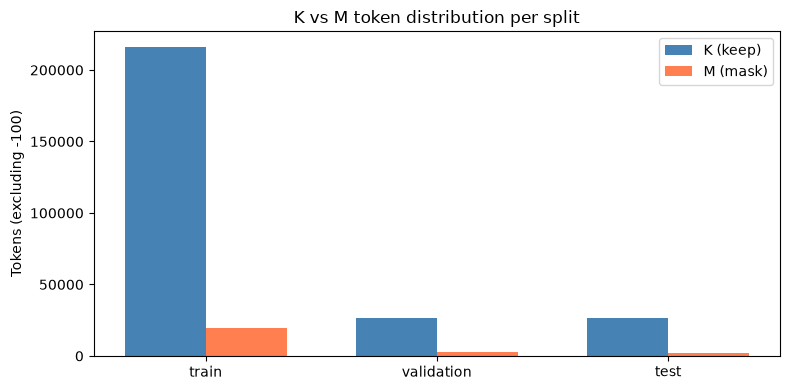

Note: K vastly outnumbers M in every split -- this is why token
accuracy alone is a misleading metric (see Section 7).


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(audit_df))
w = 0.35
ax.bar([i - w / 2 for i in x], audit_df["tokens_K"], w, label="K (keep)", color="steelblue")
ax.bar([i + w / 2 for i in x], audit_df["tokens_M"], w, label="M (mask)", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(audit_df["split"])
ax.set_ylabel("Tokens (excluding -100)")
ax.set_title("K vs M token distribution per split")
ax.legend()
plt.tight_layout()
plt.show()

print("Note: K vastly outnumbers M in every split -- this is why token")
print("accuracy alone is a misleading metric (see Section 7).")


## 4. Visual examples

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def render_example(split: str, index: int) -> pd.DataFrame:
    input_ids = dataset[split]["input_ids"][index]
    attention_mask = dataset[split]["attention_mask"][index]
    labels = dataset[split]["labels"][index]
    tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())

    rows = []
    for token, label, mask in zip(tokens, labels.tolist(), attention_mask.tolist()):
        if label == LABEL_IGNORE:
            continue
        rows.append({
            "token": token,
            "label": "M" if label == LABEL_MASK else "K",
            "attention_mask": mask,
        })
    return pd.DataFrame(rows)


def print_example(split: str, index: int) -> None:
    sentence = dataset[split]["sentences"][index]
    print(f"[{split} #{index}] {sentence}")
    df = render_example(split, index)
    highlighted = " ".join(
        f"**{row.token}**" if row.label == "M" else row.token
        for row in df.itertuples()
    )
    print(f"  {highlighted}")
    print()


/home/kenai/projects/responsible-ai-system-design/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
print("=== 5 examples from train ===\n")
for i in range(5):
    print_example("train", i)


=== 5 examples from train ===

[train #0] Besides football , the VfL Bochum operates the following kinds of sport : Badminton , Basketball , Fencing , Ice hockey , athletics , Handball , Swimming , dance sport , Tennis , Table tennis and Volleyball .
  besides football , the vfl bo ##chu ##m operates the **following** kinds of sport : badminton , basketball , fencing , ice hockey , **athletics** , handball , swimming , dance sport , tennis , table tennis and volleyball .

[train #1] At the scientific level of the debate , the crucial question was whether the `` threshold theory '' was valid or whether , as Lewis insisted , the effects of radioactivity were `` linear with no threshold '' , where every exposure to radiation had a long-term cumulative effect .
  at the scientific **level** of the debate , the **crucial** **question** was whether the ` ` threshold theory ' ' was **valid** or whether , as lewis insisted , the effects of radio ##act ##ivity were ` ` **linear** with no thresh

In [10]:
print("=== 5 examples from validation ===\n")
for i in range(5):
    print_example("validation", i)


=== 5 examples from validation ===

[validation #0] Following the September 11 , 2001 attacks , the start of the third season was postponed for a week , as were most American television premieres that year .
  **following** the september 11 , 2001 attacks , the start of the third season was **postponed** for a week , as were most american television premiere ##s **that** year .

[validation #1] She removes the gag from his mouth .
  she **removes** the gag from his mouth .

[validation #2] Haynes learned to dribble the basketball from his sisters . His skills may have been helped by handling the ball on the dirt courts of his hometown .
  haynes **learned** to **dr** **##ib** **##ble** the basketball from his sisters . his skills may have been helped by handling the ball on the dirt courts of his hometown .

[validation #3] `` That 's why he left without telling her , but Clarence told me she was ready , even then .
  ` ` **that** ' s why he left without telling her , but clarence told

In [11]:
render_example("train", 0)


,token,label,attention_mask
0,besides,K,1
1,football,K,1
2,",",K,1
3,the,K,1
4,vfl,K,1
5,bo,K,1
6,##chu,K,1
7,##m,K,1
8,operates,K,1
9,the,K,1


## 5. Train or load

Set `TRAIN_MODEL = True` to train a new lexical-baseline checkpoint from `MODEL_NAME` using `train_edit_predictor()`.

Set it to `False` to load an existing checkpoint from `OUTPUT_DIR` and evaluate it instead.

The checkpoint selected by training is the epoch with best validation `f1_M`, not best token accuracy.


In [12]:
TRAIN_MODEL = True


In [13]:
import importlib

import explanation.model.train_edit_predictor as train_edit_predictor_module

train_edit_predictor_module = importlib.reload(train_edit_predictor_module)
train_edit_predictor = train_edit_predictor_module.train_edit_predictor

print(f"Notebook device: {DEVICE}")

if TRAIN_MODEL:
    print(
        f"Starting training -- epochs={EPOCHS}, batch={BATCH_SIZE}, "
        f"lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}, "
        f"use_class_weights={USE_CLASS_WEIGHTS}, mask_class_weight={MASK_CLASS_WEIGHT}"
    )
    result = train_edit_predictor(
        dataset_file=DATASET_FILE,
        output_dir=OUTPUT_DIR,
        model_name=MODEL_NAME,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        seed=SEED,
        use_class_weights=USE_CLASS_WEIGHTS,
        mask_class_weight=MASK_CLASS_WEIGHT,
        load_mode="base",
    )
    print("Training complete.")
    print(f"  best_epoch           : {result.best_epoch}")
    print(f"  best_validation_f1_M : {result.best_validation_f1_M:.4f}")
    print(f"  test_f1_M            : {result.test_metrics['f1_M']:.4f}")
else:
    print("TRAIN_MODEL is False -- loading existing checkpoint instead.")
    if not OUTPUT_DIR.exists():
        raise FileNotFoundError(f"Checkpoint not found: {OUTPUT_DIR}")

    from torch.utils.data import DataLoader, TensorDataset

    from explanation.model.edit_predictor import EditPredictor, LABEL_IGNORE as _LABEL_IGNORE
    from explanation.model.train_edit_predictor import _evaluate

    predictor = EditPredictor.from_checkpoint(OUTPUT_DIR)
    predictor.model.to(DEVICE)

    test_split = dataset["test"]
    test_dataset = TensorDataset(
        test_split["input_ids"], test_split["attention_mask"], test_split["labels"]
    )
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    criterion = torch.nn.CrossEntropyLoss(ignore_index=_LABEL_IGNORE)

    loaded_metrics, _, _ = _evaluate(predictor.model, test_loader, DEVICE, criterion, torch)
    print("Loaded checkpoint test metrics:")
    print(json.dumps(loaded_metrics, indent=2))


Notebook device: cuda:0
Starting training -- epochs=12, batch=16, lr=2e-05, weight_decay=0.01, use_class_weights=True, mask_class_weight=None
Selected device: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2009.64it/s]
[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using class weights [K, M]: [0.545691875817991, 5.971432186234818]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.21it/s]


Epoch 1/12 - train_loss=0.2846 val_loss=0.1640 val_f1_M=0.6648 val_token_acc=0.9165


...

Epoch 8/12 - train_loss=0.0080 val_loss=0.2247 val_f1_M=0.9129 val_token_acc=0.9847
Epoch 9/12 - train_loss=0.0075 val_loss=0.2027 val_f1_M=0.9088 val_token_acc=0.9837


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


Epoch 10/12 - train_loss=0.0054 val_loss=0.2302 val_f1_M=0.9186 val_token_acc=0.9858
Epoch 11/12 - train_loss=0.0054 val_loss=0.2285 val_f1_M=0.9178 val_token_acc=0.9855
Epoch 12/12 - train_loss=0.0064 val_loss=0.1700 val_f1_M=0.9055 val_token_acc=0.9830


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2627.04it/s]


Training complete.
  best_epoch           : 10
  best_validation_f1_M : 0.9186
  test_f1_M            : 0.9189


## 6. Training curves

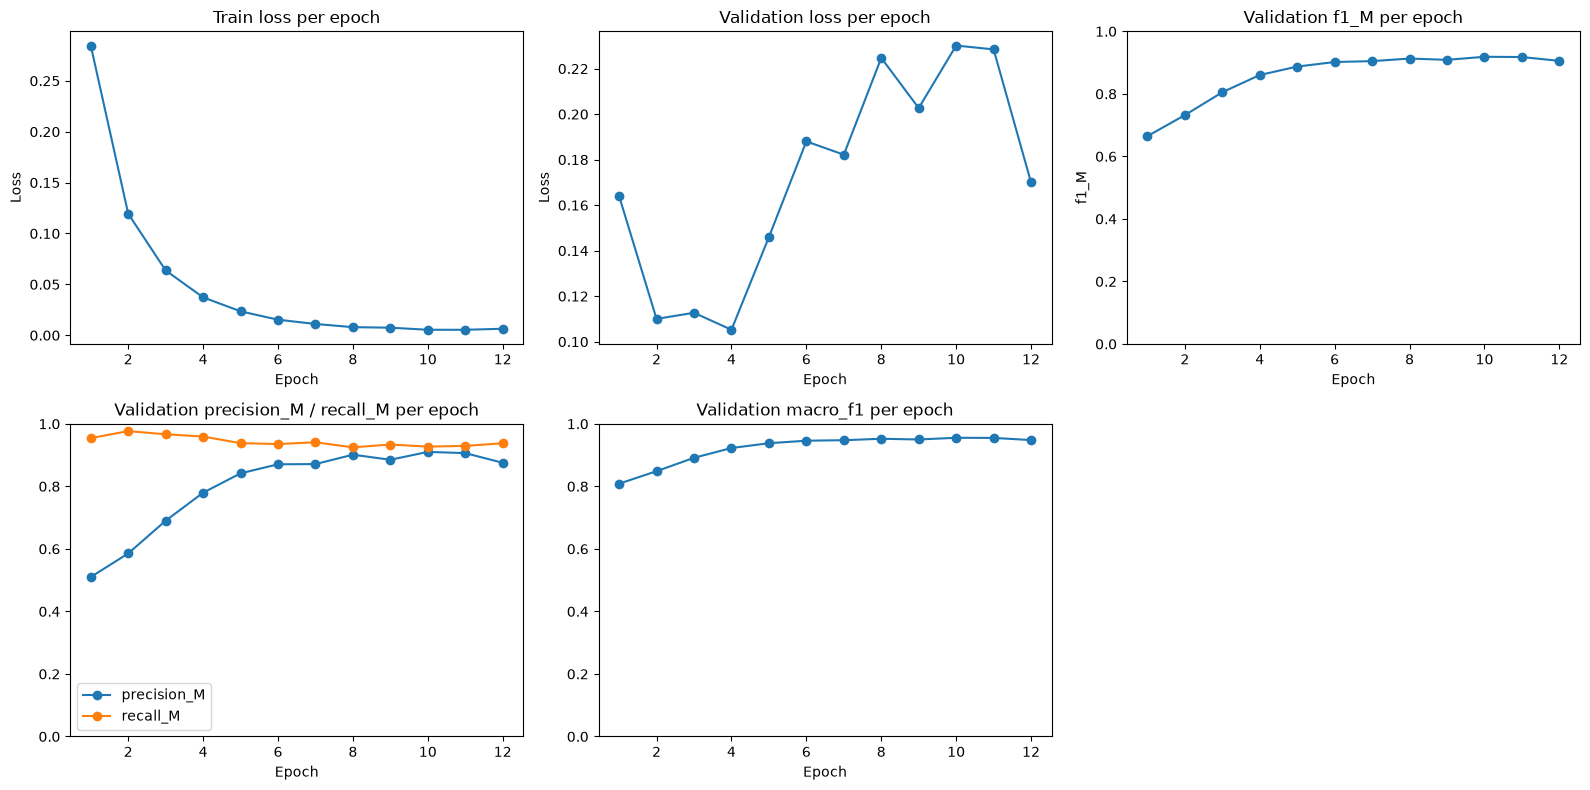

=== Best epoch (by validation f1_M) ===
  best_epoch           : 10
  best_validation_f1_M : 0.9186


In [14]:
history_path = OUTPUT_DIR / "history.csv"
metrics_path = OUTPUT_DIR / "metrics.json"

if not history_path.exists():
    print(f"No training history found at {history_path}.")
    print("Run Section 5 with TRAIN_MODEL = True first, or point OUTPUT_DIR to an existing checkpoint.")
    saved_metrics = None
else:
    history_df = pd.read_csv(history_path)
    saved_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], marker="o")
    axes[0, 0].set_title("Train loss per epoch")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")

    axes[0, 1].plot(history_df["epoch"], history_df["validation_loss"], marker="o")
    axes[0, 1].set_title("Validation loss per epoch")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Loss")

    axes[0, 2].plot(history_df["epoch"], history_df["validation_f1_M"], marker="o")
    axes[0, 2].set_title("Validation f1_M per epoch")
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].set_ylabel("f1_M")
    axes[0, 2].set_ylim(0, 1)

    axes[1, 0].plot(history_df["epoch"], history_df["validation_precision_M"], marker="o", label="precision_M")
    axes[1, 0].plot(history_df["epoch"], history_df["validation_recall_M"], marker="o", label="recall_M")
    axes[1, 0].set_title("Validation precision_M / recall_M per epoch")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["validation_macro_f1"], marker="o")
    axes[1, 1].set_title("Validation macro_f1 per epoch")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylim(0, 1)

    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

    print("=== Best epoch (by validation f1_M) ===")
    print(f"  best_epoch           : {saved_metrics['best_epoch']}")
    print(f"  best_validation_f1_M : {saved_metrics['best_validation_f1_M']:.4f}")


## 7. Final evaluation

In [15]:
from explanation.model.edit_predictor import EditPredictor, LABEL_IGNORE as _LABEL_IGNORE
from torch.utils.data import DataLoader, TensorDataset
from explanation.model.train_edit_predictor import _evaluate, compute_all_keep_baseline

best_predictor = EditPredictor.from_checkpoint(OUTPUT_DIR)
best_predictor.model.to(DEVICE)

test_split = dataset["test"]
test_dataset = TensorDataset(
    test_split["input_ids"], test_split["attention_mask"], test_split["labels"]
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
criterion = torch.nn.CrossEntropyLoss(ignore_index=_LABEL_IGNORE)

test_metrics, test_true_flat, test_pred_flat = _evaluate(
    best_predictor.model, test_loader, DEVICE, criterion, torch
)
baseline_all_keep = compute_all_keep_baseline(test_true_flat)

comparison_df = pd.DataFrame([
    {"metric": key, "model": test_metrics.get(key), "all_K_baseline": baseline_all_keep.get(key)}
    for key in ["token_accuracy", "precision_M", "recall_M", "f1_M", "macro_f1"]
])
print("=== Test metrics vs. all-K baseline ===")
print(comparison_df.to_string(index=False))


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 3008.34it/s]


=== Test metrics vs. all-K baseline ===
        metric    model  all_K_baseline
token_accuracy 0.986296        0.916912
   precision_M 0.904071        0.000000
      recall_M 0.934194        0.000000
          f1_M 0.918886        0.000000
      macro_f1 0.955701        0.478328


**Why f1_M matters more than token accuracy:** K tokens vastly outnumber M tokens in this dataset. In your lexical dataset build, the valid-token distribution was strongly imbalanced, with far fewer `M` tokens than `K` tokens. A model that always predicts `K` can score a high token accuracy while never detecting a single difficult word -- its `f1_M` is `0.0`.

Because this system's purpose is finding difficult words, `f1_M` and the precision/recall tradeoff for class `M` are the primary metrics. Token accuracy is secondary.


## 8. Error inspection

In [16]:
def predict_test_example(index: int):
    input_ids = test_split["input_ids"][index:index + 1].to(DEVICE)
    attention_mask = test_split["attention_mask"][index:index + 1].to(DEVICE)
    with torch.no_grad():
        outputs = best_predictor.model(input_ids=input_ids, attention_mask=attention_mask)
    pred_ids = outputs.logits.argmax(dim=-1)[0].cpu().tolist()

    gold_ids = test_split["labels"][index].tolist()
    tokens = tokenizer.convert_ids_to_tokens(test_split["input_ids"][index].tolist())

    rows = []
    for token, gold, pred in zip(tokens, gold_ids, pred_ids):
        if gold == _LABEL_IGNORE:
            continue
        if gold == LABEL_MASK and pred == LABEL_MASK:
            tag = "TP_M"
        elif gold == LABEL_KEEP and pred == LABEL_MASK:
            tag = "FP_M"
        elif gold == LABEL_MASK and pred == LABEL_KEEP:
            tag = "FN_M"
        else:
            tag = "TN"
        rows.append({"token": token, "gold": "M" if gold == LABEL_MASK else "K",
                     "pred": "M" if pred == LABEL_MASK else "K", "tag": tag})
    return rows


n_test = test_split["input_ids"].shape[0]
missed_m_examples = []      # has an FN_M
extra_m_examples = []       # has an FP_M
correct_m_examples = []     # has TP_M and no FP_M/FN_M

for index in range(n_test):
    rows = predict_test_example(index)
    tags = {row["tag"] for row in rows}
    if "FN_M" in tags:
        missed_m_examples.append((index, rows))
    if "FP_M" in tags:
        extra_m_examples.append((index, rows))
    if "TP_M" in tags and "FN_M" not in tags and "FP_M" not in tags:
        correct_m_examples.append((index, rows))

print(f"Examples with at least one missed M (FN_M) : {len(missed_m_examples)}")
print(f"Examples with at least one extra M (FP_M)  : {len(extra_m_examples)}")
print(f"Examples with only correct M matches       : {len(correct_m_examples)}")


Examples with at least one missed M (FN_M) : 98
Examples with at least one extra M (FP_M)  : 178
Examples with only correct M matches       : 709


In [17]:
def print_error_example(index: int, rows: list[dict]) -> None:
    sentence = dataset["test"]["sentences"][index]
    print(f"[test #{index}] {sentence}")
    rendered = " ".join(
        f"{row['token']}({row['tag']})" if row["tag"] != "TN" else row["token"]
        for row in rows
    )
    print(f"  {rendered}")
    print()


print("=== Missed M tokens (FN_M) -- model failed to flag a difficult word ===\n")
for index, rows in missed_m_examples[:3]:
    print_error_example(index, rows)

print("=== Extra M tokens (FP_M) -- model over-flagged a normal word ===\n")
for index, rows in extra_m_examples[:3]:
    print_error_example(index, rows)

print("=== Correct M matches (TP_M only) ===\n")
for index, rows in correct_m_examples[:3]:
    print_error_example(index, rows)


=== Missed M tokens (FN_M) -- model failed to flag a difficult word ===

[test #5] It is highly irrigated , well peopled , and crowded with small fortified villages , orchards and groves , to which a fine background is afforded by the dark pine forests and alpine snows of the Safed Koh .
  it is highly ir ##ri ##gated , well people ##d , and crowded with small fortified villages , orchards(FN_M) and groves , to which a fine(TP_M) background is afforded by the dark pine(TP_M) forests and alpine snow ##s of the safe ##d ko ##h .

[test #9] The Grand Duchy of Tuscany -LRB- Italian : Granducato di Toscana , Latin : Magnus Ducatus Etruriae -RRB- was a central Italian monarchy that existed , with interruptions , from 1569 to 1859 , replacing the Duchy of Florence .
  the grand(TP_M) duchy of tuscany - l ##rb - italian : grand ##uca ##to di to ##scan ##a , latin : magnus duc ##atus et ##ru ##ria ##e - rr ##b - was a central italian monarchy that(TP_M) existed(TP_M) , with interruption(FN_M) #

## 9. Save summary

In [18]:
metrics_path = OUTPUT_DIR / "metrics.json"
if not metrics_path.exists():
    raise FileNotFoundError(
        f"metrics.json not found at {metrics_path}. Run training/evaluation first."
    )

saved_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))

summary = {
    "pseudo_label_file": str(PSEUDO_LABEL_FILE),
    "dataset_file": str(DATASET_FILE),
    "checkpoint_path": str(OUTPUT_DIR),
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "mask_class_weight": MASK_CLASS_WEIGHT,
    "best_validation_epoch": saved_metrics["best_epoch"],
    "best_validation_f1_M": saved_metrics["best_validation_f1_M"],
    "test_f1_M": test_metrics["f1_M"],
    "test_precision_M": test_metrics["precision_M"],
    "test_recall_M": test_metrics["recall_M"],
    "test_token_accuracy": test_metrics["token_accuracy"],
    "all_K_baseline_f1_M": baseline_all_keep["f1_M"],
    "all_K_baseline_token_accuracy": baseline_all_keep["token_accuracy"],
}

summary_path = OUTPUT_DIR / "notebook_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True), encoding="utf-8")

print(f"Summary saved to: {summary_path}")
print(json.dumps(summary, indent=2, sort_keys=True))


Summary saved to: /home/kenai/projects/responsible-ai-system-design/explanation/model/checkpoints/edit_predictor_complex_words_distilbert_max256_big_final/notebook_summary.json
{
  "all_K_baseline_f1_M": 0.0,
  "all_K_baseline_token_accuracy": 0.916912,
  "batch_size": 16,
  "best_validation_epoch": 10,
  "best_validation_f1_M": 0.918634,
  "checkpoint_path": "/home/kenai/projects/responsible-ai-system-design/explanation/model/checkpoints/edit_predictor_complex_words_distilbert_max256_big_final",
  "dataset_file": "/home/kenai/projects/responsible-ai-system-design/explanation/data/processed/edit_predictor_token_labels_complex_words_distilbert_max256.pt",
  "epochs": 12,
  "learning_rate": 2e-05,
  "mask_class_weight": null,
  "max_length": 256,
  "model_name": "distilbert-base-uncased",
  "pseudo_label_file": "/home/kenai/projects/responsible-ai-system-design/explanation/data/processed/complex_words_pseudo_labels.jsonl",
  "test_f1_M": 0.918886,
  "test_precision_M": 0.904071,
  "test_